# Increasing the Vibrance

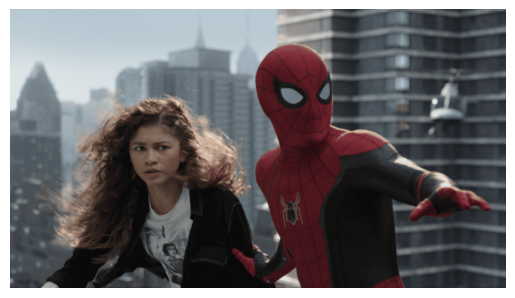

In [ ]:
# import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt


# parameters
sigma = 70.0
alpa = 0.5   #initial alpha value

image = cv2.imread('spider.png')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis('off')
plt.show()
                

(a)Convert to H, S, V planes

In [30]:
# h-(0-179), s-(0-255), v-(0-255)
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV).astype(np.float32)

# convert to H, S, V planes
h, s, v = cv2.split(hsv)


(b)Transformation

In [31]:
# Vibrance transformation function
def vibrance_transform(s_plane, a_val, sigma_val=70.0):
    # operate elementwise; s_plane expected 0..255 floats or ints
    x = s_plane.astype(np.float32)
    bump = a_val * 128.0 * np.exp(-((x - 128.0) ** 2) / (2.0 * (sigma_val ** 2)))
    out = x + bump
    out = np.minimum(out, 255.0)
    return out

alpa = 0.75
# Apply vibrance transformation to S plane
S_enhanced = vibrance_transform(S, alpa, sigma)
  

(d) Combine planes

In [32]:
# Convert back to BGR 
hsv_enhanced = np.stack([H, S_enhanced, V], axis=2).astype(np.uint8)
bgr_enhanced = cv2.cvtColor(hsv_enhanced, cv2.COLOR_HSV2BGR)

# Convert BGR to RGB
rgb_original = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
rgb_enhanced  = cv2.cvtColor(bgr_enhanced, cv2.COLOR_BGR2RGB)

(c) Visualize to change alpha

when alpha was 0.75 image looked visually pleasing

(np.float64(-0.5), np.float64(779.5), np.float64(437.5), np.float64(-0.5))

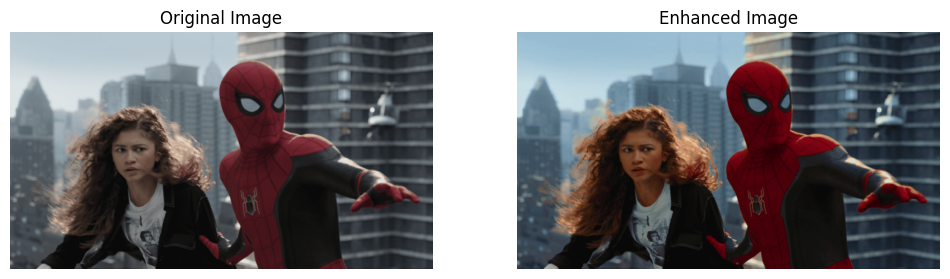

In [33]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(rgb_original)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rgb_enhanced)
plt.title('Enhanced Image')
plt.axis('off')

(d) Display the original image, vibrance-enhanced image, and the intensity transformation.

create transformation curve

In [23]:
xs = np.arange(256, dtype=np.float32)
ys = np.minimum(xs + alpa * 128.0 * np.exp(-((xs - 128.0) ** 2) / (2.0 * (sigma ** 2))), 255.0)

display transform curve

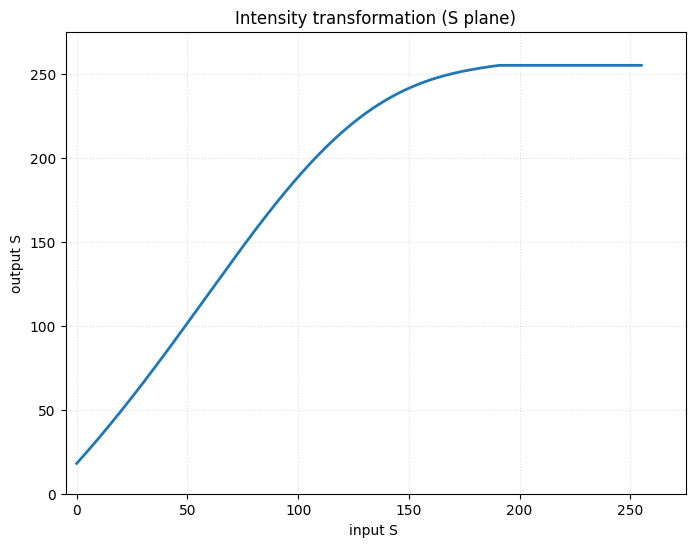

In [28]:
plt.figure(figsize=(8, 6))
plt.plot(xs, ys, linewidth=2)
plt.title("Intensity transformation (S plane)")
plt.xlabel("input S ")
plt.ylabel("output S")
plt.xlim(-5,275)
plt.ylim(0,275)
plt.grid(True, linestyle=':', alpha=0.4)

Display original and enhanced image

(np.float64(-0.5), np.float64(779.5), np.float64(437.5), np.float64(-0.5))

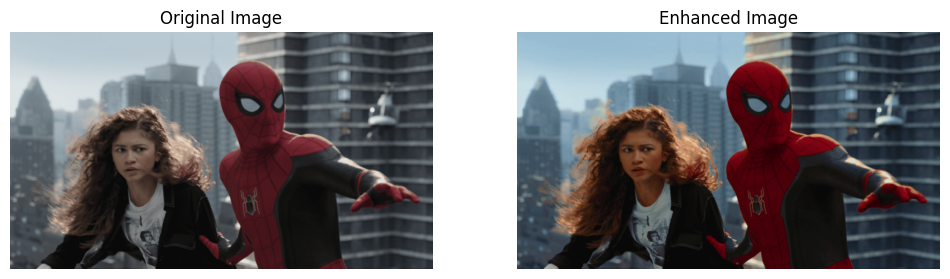

In [29]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(rgb_original)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rgb_enhanced)
plt.title('Enhanced Image')
plt.axis('off')